### Q4

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

In [11]:
df_raw = pd.read_csv('../../data/Divar.csv')

C:\Users\M.Ali\AppData\Local\Temp\ipykernel_5664\4111837363.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../../data/Divar.csv')


In [16]:
# تفکیک آگهی‌های فروش
df_clean = df_raw.dropna(subset=['cat2_slug']).copy()
df_sale = df_clean[df_clean['cat2_slug'].str.contains('sell', case=False, na=False)].copy()

# تبدیل ستون‌های کلیدی به عددی و حذف مقادیر خالی
df_sale['price_value'] = pd.to_numeric(df_sale['price_value'], errors='coerce')
df_sale['building_size'] = pd.to_numeric(df_sale['building_size'], errors='coerce')
df_sale = df_sale.dropna(subset=['price_value', 'building_size'])

# فیلتر داده‌های پرت با روش IQR 
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_sale_filtered = remove_outliers_iqr(df_sale, 'price_value')
df_sale_filtered = remove_outliers_iqr(df_sale_filtered, 'building_size')

# استخراج ویژگی‌ها
luxury_keywords = ['استخر', 'باربیکیو', 'سونا', 'جکوزی']
non_luxury_keywords = ['پارکینگ', 'آسانسور', 'انباری', 'بالکن']
df_sale_filtered['description'] = df_sale_filtered['description'].fillna('')

# شناسایی خانه‌های لاکچری
df_sale_filtered['has_luxury'] = df_sale_filtered['description'].apply(
    lambda x: any(keyword in x for keyword in luxury_keywords)
)

# حذف خانه‌های لاکچری 
df_fair = df_sale_filtered[df_sale_filtered['has_luxury'] == False].copy()

# بررسی امکانات پایه روی خانه‌های غیرلاکچری
df_fair['has_non_luxury'] = df_fair['description'].apply(
    lambda x: any(keyword in x for keyword in non_luxury_keywords)
)

# تفکیک متغیر هدف به دو گروه مستقل
prices_with_non_luxury = df_fair[df_fair['has_non_luxury'] == True]['price_value']
prices_without_non_luxury = df_fair[df_fair['has_non_luxury'] == False]['price_value']

print(f"تعداد خانه‌های دارای امکانات پایه: {len(prices_with_non_luxury):,}")
print(f"میانگین قیمت این گروه: {prices_with_non_luxury.mean():,.0f} تومان")
print("-" * 40)
print(f"تعداد خانه‌های بدون امکانات پایه: {len(prices_without_non_luxury):,}")
print(f"میانگین قیمت این گروه: {prices_without_non_luxury.mean():,.0f} تومان")
print("=" * 50)

# استفاده از T-Test مستقل با فرض برابری واریانس‌ها (equal_var=True)
t_stat, p_value = stats.ttest_ind(prices_with_non_luxury, prices_without_non_luxury, equal_var=True)

print(f"(t-value): {t_stat:.4f}")
print(f"(p-value): {p_value:.5f}")
print("=" * 50)
 
alpha = 0.05
if p_value < alpha:
    print(f"چون p-value کوچکتر از سطح معناداری {alpha} است، فرض صفر (H0) رد می‌شود.")
    print("تفاوت میانگین قیمت دو گروه از نظر آماری کاملاً معنادار است")
else:
    print(f"چون p-value بزرگتر از سطح معناداری {alpha} است، شواهد کافی برای رد فرض صفر (H0) وجود ندارد.")
    print("تفاوت معناداری بین میانگین قیمت دو گروه وجود ندارد")

تعداد خانه‌های دارای امکانات پایه: 171,917
میانگین قیمت این گروه: 3,807,845,272 تومان
----------------------------------------
تعداد خانه‌های بدون امکانات پایه: 271,766
میانگین قیمت این گروه: 3,050,556,056 تومان
(t-value): 90.9385
(p-value): 0.00000
چون p-value کوچکتر از سطح معناداری 0.05 است، فرض صفر (H0) رد می‌شود.
تفاوت میانگین قیمت دو گروه از نظر آماری کاملاً معنادار است


میانگین متراژ خانه‌های دارای امکانات پایه: 95 متر
میانگین متراژ خانه‌های فاقد امکانات پایه: 124 متر
--------------------------------------------------


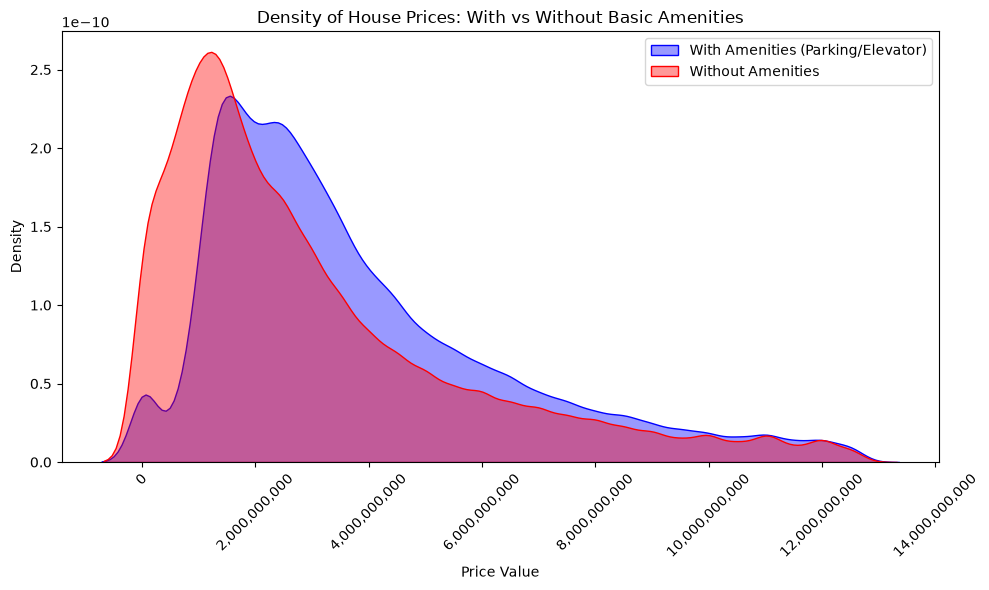

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# بررسی متغیر  متراژ
size_with = df_fair[df_fair['has_non_luxury'] == True]['building_size'].mean()
size_without = df_fair[df_fair['has_non_luxury'] == False]['building_size'].mean()

print(f"میانگین متراژ خانه‌های دارای امکانات پایه: {size_with:.0f} متر")
print(f"میانگین متراژ خانه‌های فاقد امکانات پایه: {size_without:.0f} متر")
print("-" * 50)

# رسم نمودار چگالی (KDE) برای مشاهده تفاوت توزیع قیمت‌ها
plt.figure(figsize=(10, 6))

sns.kdeplot(
    prices_with_non_luxury, 
    label='With Amenities (Parking/Elevator)', 
    fill=True, 
    color='blue', 
    alpha=0.4
)
sns.kdeplot(
    prices_without_non_luxury, 
    label='Without Amenities', 
    fill=True, 
    color='red', 
    alpha=0.4
)

plt.title('Density of House Prices: With vs Without Basic Amenities')
plt.xlabel('Price Value')
plt.ylabel('Density')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Mann-Whitney U Test

u_stat, p_value_mwu = stats.mannwhitneyu(
    prices_with_non_luxury, 
    prices_without_non_luxury, 
    alternative='two-sided'
)

print(f"(U-statistic): {u_stat:,.0f}")
print(f"(p-value): {p_value_mwu:.5e}")
print("=" * 50)

alpha = 0.05
if p_value_mwu < alpha:
    print("نتیجه آزمون: فرض صفر رد می‌شود")
else:
    print("نتیجه آزمون: فرض صفر رد نمی‌شود")

(U-statistic): 28,709,843,148
(p-value): 0.00000e+00
نتیجه آزمون: فرض صفر رد می‌شود
